<a href="https://colab.research.google.com/github/IzanPereira/N-cleo-CD---Analisando-dados-com-Polars/blob/main/N%C3%BAcleo_de_CD_Semana_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# Importando a biblioteca polars
import polars as pl

In [39]:
#Lendo a o dataset winemag-data_first150k
wine = pl.read_csv('winemag-data_first150k.csv')

In [40]:
#imprimindo a o cabeçalho
#lendo as 5 primeiras linhas
wine.head(5)

,country,description,designation,points,price,province,region_1,region_2,variety,winery
i64,str,str,str,i64,f64,str,str,str,str,str
0,"""US""","""This tremendous 100% varietal …","""Martha's Vineyard""",96,235.0,"""California""","""Napa Valley""","""Napa""","""Cabernet Sauvignon""","""Heitz"""
1,"""Spain""","""Ripe aromas of fig, blackberry…","""Carodorum Selección Especial R…",96,110.0,"""Northern Spain""","""Toro""",null,"""Tinta de Toro""","""Bodega Carmen Rodríguez"""
2,"""US""","""Mac Watson honors the memory o…","""Special Selected Late Harvest""",96,90.0,"""California""","""Knights Valley""","""Sonoma""","""Sauvignon Blanc""","""Macauley"""
3,"""US""","""This spent 20 months in 30% ne…","""Reserve""",96,65.0,"""Oregon""","""Willamette Valley""","""Willamette Valley""","""Pinot Noir""","""Ponzi"""
4,"""France""","""This is the top wine from La B…","""La Brûlade""",95,66.0,"""Provence""","""Bandol""",null,"""Provence red blend""","""Domaine de la Bégude"""


In [41]:
wine.null_count() #Estou olhando todas as colunas que possuem os nulos
                  #Para se ter uma noção de todas as colunas

,country,description,designation,points,price,province,region_1,region_2,variety,winery
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,5,0,45735,0,13695,5,25060,89977,0,0


In [42]:
nulos = wine.select(pl.col('price').null_count())
#para buscar somente os nulos presentes na coluna de interesse
#no caso a coluna price onde queremos inputar novos dados
#utilizei do .select definindo pl.col como 'price' e o .null_count, ou seja
#selecione a coluna price e faça a contagem
print(nulos) #como mostrado tem 13695 campos nulos na coluna price

shape: (1, 1)
┌───────┐
│ price │
│ ---   │
│ u32   │
╞═══════╡
│ 13695 │
└───────┘


In [43]:
wine = wine.with_columns(pl.col('price').fill_null(
    pl.col('price').median().over(['country', 'variety'])))
#estou inputando diretamente no wine, utilizando with_columns para chamar
#a coluna e interesse 'price' e com fill_null estou imputando a .median()
#em 'price' respeitando a mediana de 'country' e 'variety'.
#para que não faça o calculo geral da mediana de toda a coluna, o que
#deixaria os valores "incorreto", pois, diferentes países praticam
#valores diferentes para a mesma variedade de vinho/uva


In [48]:
novacontagemnull = wine.select(pl.col('price').null_count())
#verificando se ainda existe nulos
print(novacontagemnull) #observasse que a coluna ainda tem 59 nulos
                        # que precisamos verificar do que se tratam

shape: (1, 1)
┌───────┐
│ price │
│ ---   │
│ u32   │
╞═══════╡
│ 59    │
└───────┘


In [49]:
sempreço = wine.filter(pl.col('price').is_null())
#usei o filter para buscar somente na coluna 'price' os nulos com
# .is_null()
print(sempreço['price','variety', 'country'])
#imprimi os nulos de price, juntamente com a variedade e país

shape: (59, 3)
┌───────┬────────────────────────────────┬─────────────┐
│ price ┆ variety                        ┆ country     │
│ ---   ┆ ---                            ┆ ---         │
│ f64   ┆ str                            ┆ str         │
╞═══════╪════════════════════════════════╪═════════════╡
│ null  ┆ Fiano                          ┆ US          │
│ null  ┆ Sauvignon Blanc-Sauvignon Gris ┆ France      │
│ null  ┆ Sacy                           ┆ France      │
│ null  ┆ Malbec Blend                   ┆ France      │
│ null  ┆ Gelber Traminer                ┆ Austria     │
│ …     ┆ …                              ┆ …           │
│ null  ┆ Zinfandel                      ┆ Chile       │
│ null  ┆ White Blend                    ┆ Tunisia     │
│ null  ┆ Alicante Bouschet              ┆ Australia   │
│ null  ┆ Merlot-Syrah                   ┆ France      │
│ null  ┆ Zweigelt                       ┆ New Zealand │
└───────┴────────────────────────────────┴─────────────┘


In [75]:
wine = wine.with_columns(pl.col('price').fill_null(
    pl.col('price').median().over(['points'])))
wine.select(pl.col('price').null_count())
#teste algumas combinações como 'variety' e 'region_1', porém ainda
#restava uma quantidade de 21 ou 19 nulos, dai usei somente
#winery, o que deixou uma quantidade de 17 nulos
#dai estou usando somente points que conseguiu imputar todos os 59 nulos
#que restaram da primeira imputação
#porque disso, claro que em uma quantidade maior de colunas, não
#é viável essa manipulação, parte do princípio que as colunas que não
#tinha falta de dados, poderiam ter valores correspondentes que pudesse
#usar na ultima ultima imputação, e points foi uma delas, utilizei a mesma
#estrutura de codigo anterior, ou seja, o metodo pela mediana
#outra coisa é que quando usa variedade, podemos nos deparar com situações
#endêmicas o que dificulta a imupatação.

price
u32
0


In [74]:
WineUS = wine.filter((pl.col("country") == 'US'))
#Criando o dataset WineUS para coletar somente os dados dos vinhos
#de US do dataset original wine

In [76]:
q1 = WineUS.select(pl.col("price").quantile(0.25)).item()
q3 = WineUS.select(pl.col("price").quantile(0.75)).item()
IQR = q3 - q1
LimiteS= q3 + 1.5 * IQR
LimiteI= q1 - 1.5 * IQR
print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {IQR}")
print(f"Limite Superior: {LimiteS}")
print(f"Limite Inferior: {LimiteI}")
#utilizando o .select vamos selecionar somente os dados de interesse
#neste caso os dados da coluna 'price', depois disso utlizei o
#.quantile para definir os valores e os valores numéricos
#usando o .item()
#dai fiz os calculos e coloquei para imprimir

Q1: 19.0
Q3: 40.0
IQR: 21.0
Limite Superior: 71.5
Limite Inferior: -12.5


In [77]:
WineUS.describe() #outra opção mais rápida seria usar o .describe()
                  #nele já observamos as métricas principais de todo
                  #o dataset, porem não traz o IQR nem os limites
                  #pois o fator pode variar de analista

statistic,,country,description,designation,points,price,province,region_1,region_2,variety,winery
str,f64,str,str,str,f64,f64,str,str,str,str,str
"""count""",62397.0,"""62397""","""62397""","""40345""",62397.0,62397.0,"""62397""","""62261""","""60953""","""62397""","""62397"""
"""null_count""",0.0,"""0""","""0""","""22052""",0.0,0.0,"""0""","""136""","""1444""","""0""","""0"""
"""mean""",76073.949773,null,null,null,87.818789,33.64919,null,null,null,null,null
"""std""",43577.719275,null,null,null,3.410294,24.845912,null,null,null,null,null
"""min""",0.0,"""US""","""$10 for this very drinkable Ca…","""""M""""",80.0,4.0,"""America""","""Adelaida District""","""California Other""","""Aglianico""","""'37 Cellars"""
"""25%""",38406.0,null,null,null,85.0,19.0,null,null,null,null,null
"""50%""",76446.0,null,null,null,88.0,28.0,null,null,null,null,null
"""75%""",114322.0,null,null,null,90.0,40.0,null,null,null,null,null
"""max""",150916.0,"""US""","""“Whole cluster” refers to the …","""‘Rough Justice' Red""",100.0,2013.0,"""Washington-Oregon""","""Yountville""","""Willamette Valley""","""Zweigelt""","""àMaurice"""


In [90]:
vinhosnormais = WineUS.filter(pl.col("price") <= LimiteS)
#colocando somente no dataset vinhosnormais os vinhos abaixo do LimiteS
# dos vinho do US
#ou seja os mais 'baratos'

In [87]:
vinhosluxo = WineUS.filter(pl.col("price") > LimiteS)
#colocando somente no dataset vinhosnormais os vinhos acima do LimiteS
#os mais caros

In [91]:
vinhosnormais.select(pl.col("points").mean()).item()
#media do valor dos vinhos "baratos" esta entorno de $87,58

87.5826390069716

In [92]:
vinhosluxo.select(pl.col("points").mean()).item()
#media do valor dos vinhos "baratos" esta entorno de $91.69

91.69054920546418

In [93]:
import matplotlib.pyplot as plt

In [96]:
preçosUS = (wine.filter(pl.col("country") == "US") #filtro por US
    .select(pl.col("price"))#filtro por price
    .drop_nulls() #tirando os valores nulos do dataset, mas, não deve ter
    .to_series() # extraindo a coluna do dataset para o formato series
                  #importante transforma em series, tentei sem não deu
    .to_list()   # conversão para uma lista
)

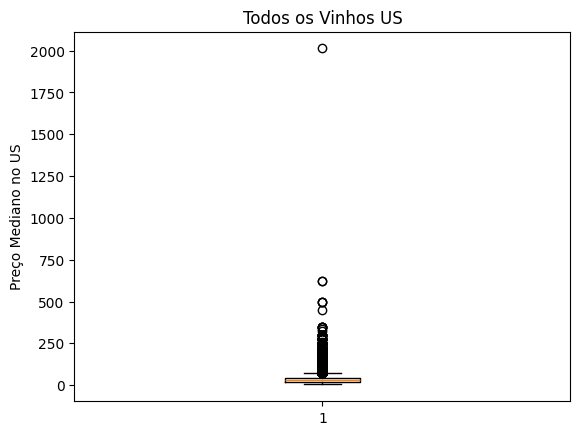

In [109]:
plt.boxplot(preçosUS)
plt.title("Todos os Vinhos US")
plt.ylabel("Preço Mediano no US")
plt.show()

Quando utilizamos somente os dados, mesmo que limpemos a visualização ficar, ruim, pois, pegar para visualizar em um box-plot mais de 15 mil informações não é possível, o gráfico fica achatado e existe muitos pontos fora dos gráfico, onde os preços são muito superiores a média deles, um grande problema quando temos outliers, dificultando a visualização clara.

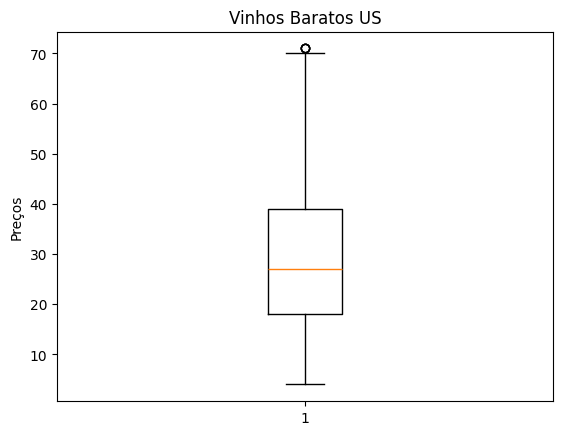

In [110]:
plt.boxplot(vinhosnormais.select(pl.col("price")).to_series().to_list())
plt.title("Vinhos Baratos US")
plt.ylabel("Preços")
plt.show()

Diferente dos outro grafico, vemos que apesar de termos vinho acima da mediana ou seja variando entre um pouco menos de $20 até $40, sabemos que a mediana dentro da caixa com valores em aproximadamente $27~28, observasse existem vinhos com valores inferiores e superiores, ou seja os 25% inferios e os 25% superior a caixa.
Mesmo com os limites ainda temos valores que ultapassam, nesse caso se trata de um outliers, ou seja, um valor fora da curva, o que em determinados dados, deve ser tratados.

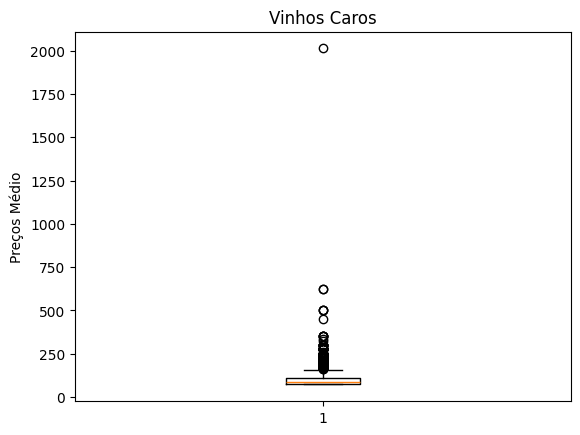

In [108]:
plt.boxplot(vinhosluxo.select(pl.col("price")).to_series().to_list())
plt.title("Vinhos Caros")
plt.ylabel("Preços Médio")
plt.show()

Quando isolamos somente os vinhos caros, observamos a mesma confusão de dados do primeiro gráfico, ou seja, existem preço fora dos limites, chegando a um valor de ~$700.